In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [4]:
example_data = pd.read_csv('../data/5/exp05H20140926_10h50.csv')

In [10]:
n = 5
separations = pd.DataFrame(index=example_data.index)

for i in range(1, n + 1):
    for j in range(i + 1, n + 1):
        separations[f"{i}_{j}"] = np.hypot(
            example_data[f"X{i}"] - example_data[f"X{j}"],
            example_data[f"Y{i}"] - example_data[f"Y{j}"]
        )

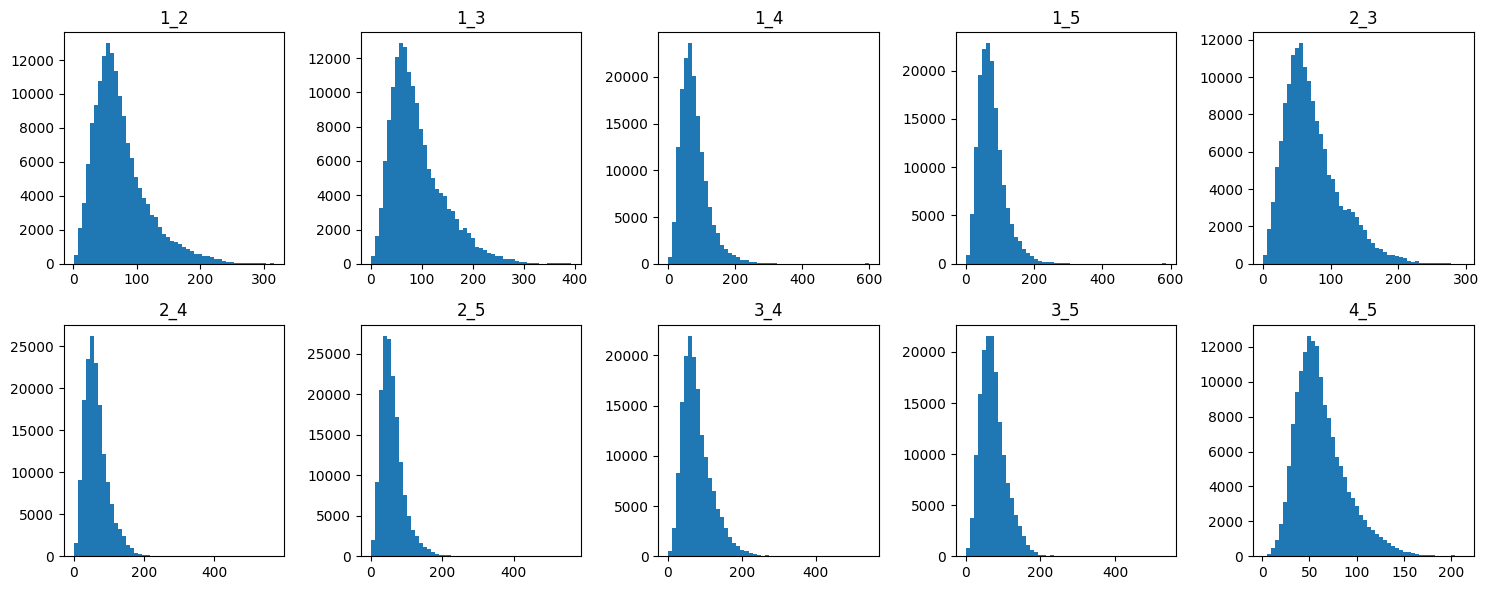

In [28]:
fig1, ((ax1,ax2,ax3,ax4,ax5),(ax6,ax7,ax8,ax9,ax10)) = plt.subplots(2,5,figsize=(15, 6))
axes = [ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9,ax10]

for i, col in enumerate(separations.columns):
    axes[i].hist(separations[col], bins=50)
    axes[i].set_title(col)

plt.tight_layout()

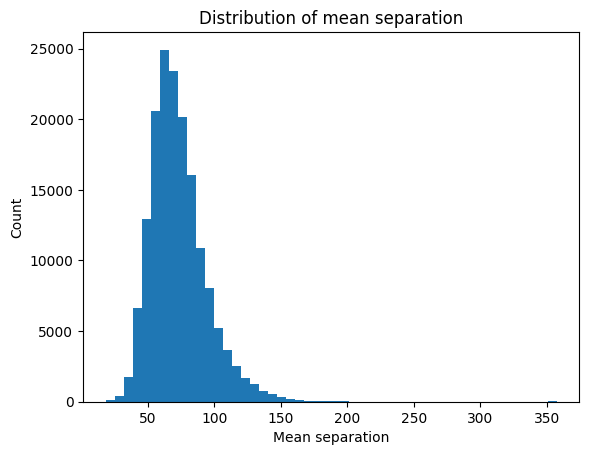

In [29]:
mean_sep = separations.mean(axis=1)

plt.hist(mean_sep, bins=50)
plt.xlabel("Mean separation")
plt.ylabel("Count")
plt.title("Distribution of mean separation")
plt.show()

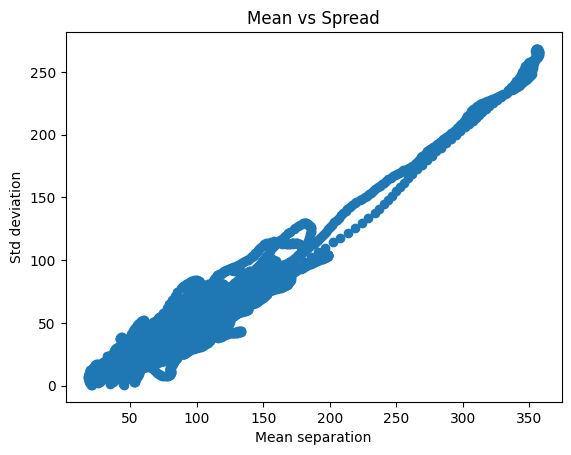

In [30]:
std_sep = separations.std(axis=1)

plt.scatter(mean_sep, std_sep)
plt.xlabel("Mean separation")
plt.ylabel("Std deviation")
plt.title("Mean vs Spread")
plt.show()

In [31]:
print(mean_sep.describe())

count    162774.000000
mean         73.335085
std          22.385868
min          18.498990
25%          58.641957
50%          69.898906
75%          83.872605
max         357.246433
dtype: float64


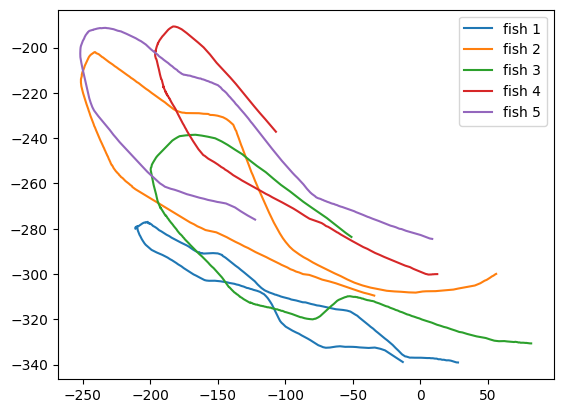

In [50]:
def plot_fish_paths(experement:pd.DataFrame) -> None :
    n_fish = experement.shape[1]//3

    for i in range(0,n_fish*3,3) :
        plt.plot(experement.iloc[:,i],experement.iloc[:,i+1],label=f'fish {1 + i//3}')

    plt.legend()
    plt.show('plots/paths.pdf')

plot_fish_paths(example_data.loc[10200:10500])

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Assuming 'example_data' (positions) and 'separations' (distances) 
# are already in your notebook's memory from your previous cells.

example_data = example_data.loc[10200:10500]
separations = separations.loc[10200:10500]

# 1. Setup the Figure and Axes (1 row, 2 columns)
fig, (ax_traj, ax_bar) = plt.subplots(1, 2, figsize=(16, 6))

# --- Setup Scatter Plot (Fish Movement) ---
# Extract coordinate column names dynamically for n=5
x_cols = [f"X{i}" for i in range(1, 6)]
y_cols = [f"Y{i}" for i in range(1, 6)]

# Find the global min and max for consistent axis limits
x_min, x_max = example_data[x_cols].min().min(), example_data[x_cols].max().max()
y_min, y_max = example_data[y_cols].min().min(), example_data[y_cols].max().max()

ax_traj.set_xlim(x_min - 10, x_max + 10) # Padding so fish don't hit the edges
ax_traj.set_ylim(y_min - 10, y_max + 10)
ax_traj.set_title("Fish Trajectories (Overhead View)", fontsize=14)
ax_traj.set_xlabel("X Coordinate")
ax_traj.set_ylabel("Y Coordinate")

# Initialize the scatter plot points
# Initialize with the first frame's data to avoid the size mismatch error
colors = ['red', 'blue', 'green', 'orange', 'purple']
initial_x = example_data[x_cols].iloc[0].values
initial_y = example_data[y_cols].iloc[0].values
scat = ax_traj.scatter(initial_x, initial_y, c=colors, s=150, edgecolors='black', zorder=5)

# --- Setup Bar Chart (Separations) ---
sep_cols = separations.columns
x_pos = np.arange(len(sep_cols))

# Initialize empty bars
bars = ax_bar.bar(x_pos, np.zeros(len(sep_cols)), color='skyblue', edgecolor='black')
ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(sep_cols, rotation=45)

# Set static Y-axis limit based on the maximum separation ever achieved
max_sep = separations.max().max()
ax_bar.set_ylim(0, max_sep * 1.1) 
ax_bar.set_title("Pairwise Separation Distances", fontsize=14)
ax_bar.set_ylabel("Distance")

# 2. The Update Function (Called once per frame)
def update(frame):
    # Update scatter plot positions
    current_x = example_data[x_cols].iloc[frame].values
    current_y = example_data[y_cols].iloc[frame].values
    scat.set_offsets(np.c_[current_x, current_y])
    
    # Update bar chart heights
    current_seps = separations.iloc[frame].values
    for bar, h in zip(bars, current_seps):
        bar.set_height(h)
        
    # Update title to show time or frame
    fig.suptitle(f"Frame: {frame}", fontsize=16, fontweight='bold')
    
    return scat, *bars

# 3. Compile the Animation
# Note: For testing, you might want to limit frames (e.g., frames=500) rather than len(example_data)
total_frames = len(example_data)
ani = animation.FuncAnimation(fig, update, frames=total_frames, interval=50, blit=False)

plt.close(fig) # Prevents the static empty plot from showing up in Jupyter

# 4. Display or Export
# To view directly inside the Jupyter Notebook:
# display(HTML(ani.to_jshtml()))

# To save as an MP4 for your video presentation (Requires FFmpeg installed):
ani.save("fish_turn_event.mp4", writer='ffmpeg', fps=20, dpi=150)

MovieWriter ffmpeg unavailable; using Pillow instead.


ValueError: unknown file extension: .mp4